In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
# df = pd.read_csv("../data/sample_submission.csv")

In [5]:
df.shape

(59381, 128)

In [6]:
df.head()

,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8


In [7]:
df.drop(columns=["Id"],inplace=True)

In [8]:
df[0:6]

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,1,D3,10,0.076923,2,1,1,0.641791,0.581818,0.148536,...,0,0,0,0,0,0,0,0,0,8
1,1,A1,26,0.076923,2,3,1,0.059701,0.600000,0.131799,...,0,0,0,0,0,0,0,0,0,4
2,1,E1,26,0.076923,2,3,1,0.029851,0.745455,0.288703,...,0,0,0,0,0,0,0,0,0,8
3,1,D4,10,0.487179,2,3,1,0.164179,0.672727,0.205021,...,0,0,0,0,0,0,0,0,0,8
4,1,D2,26,0.230769,2,3,1,0.417910,0.654545,0.234310,...,0,0,0,0,0,0,0,0,0,8
5,1,D2,26,0.230769,3,1,1,0.507463,0.836364,0.299163,...,0,0,0,0,0,0,0,0,0,8


In [24]:
df["Product_Info_3"].describe()

count    59381.000000
mean        24.415655
std          5.072885
min          1.000000
25%         26.000000
50%         26.000000
75%         26.000000
max         38.000000
Name: Product_Info_3, dtype: float64

In [46]:
import pandas as pd
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt


def summary_col(data, col):

    print(f"The column {col} is at index {data.columns.get_loc(col)}")
    print(f"Data type: {data[col].dtype}")
    print(data[col].describe())

    # ---------------- NUMERICAL ----------------
    if pd.api.types.is_numeric_dtype(data[col]):

        print("Type: Numerical")
        print(f"Missing: {data[col].isna().sum()}")
        print(f"Unique: {data[col].nunique()}")

        # Remove missing values
        clean_data = data[col].dropna()

        # Shapiro test
        if len(clean_data) > 5000:

            sample = clean_data.sample(
                n=5000,
                random_state=42
            )

            stat, p = shapiro(sample)

        else:

            stat, p = shapiro(clean_data)

        # Normality result
        if p > 0.05:

            print(f"{col} is approximately normally distributed")

        else:

            print(f"{col} is NOT normally distributed")

        print(f"Shapiro p-value: {p:.5f}")
        print("---------------------------")

        # Correlation
        if "Response" in data.columns:

            if p > 0.05:

                cor = data[col].corr(
                    data["Response"],
                    method="pearson"
                )

                print(f"Pearson correlation: {cor:.3f}")

            else:

                cor = data[col].corr(
                    data["Response"],
                    method="spearman"
                )

                print(f"Spearman correlation: {cor:.3f}")


        # Histogram
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        # Histogram
        sns.histplot(
            data=data,
            x=col,
            kde=True,
            ax=ax[0]
        )
        ax[0].set_title(f"Distribution of {col}")

        # Scatter plot
        sns.scatterplot(
            data=data,
            x=col,
            y="Response",
            ax=ax[1]
        )
        ax[1].set_title(f"{col} vs Response")

        plt.tight_layout()
        plt.show()
        return {
            "Shape": data[col].shape,
            "Number of null": data[col].isna().sum(),
            "Unique value": data[col].nunique(),
            "Correlation": cor if "Response" in data.columns else None
        }

    else:

        print("Type: Categorical")

        print(f"Missing: {data[col].isna().sum()}")
        print(f"Unique: {data[col].nunique()}")

        print("\nValue counts:")
        print(data[col].value_counts())

        # Two plots
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        # Count plot
        sns.countplot(
            data=data,
            x=col,
            ax=ax[0]
        )

        ax[0].set_title(f"Distribution of {col}")
        ax[0].tick_params(axis="x", rotation=45)

        # Categorical X → Numerical Y
        sns.boxplot(
            data=data,
            x=col,
            y="Response",
            ax=ax[1]
        )

        ax[1].set_title(f"{col} vs Response")
        ax[1].tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()

    return {
            "Shape": data[col].shape,
            "Number of null": data[col].isna().sum(),
            "Unique value": data[col].nunique()
        }

In [49]:
df.head(6)

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,1,D3,10,0.076923,2,1,1,0.641791,0.581818,0.148536,...,0,0,0,0,0,0,0,0,0,8
1,1,A1,26,0.076923,2,3,1,0.059701,0.600000,0.131799,...,0,0,0,0,0,0,0,0,0,4
2,1,E1,26,0.076923,2,3,1,0.029851,0.745455,0.288703,...,0,0,0,0,0,0,0,0,0,8
3,1,D4,10,0.487179,2,3,1,0.164179,0.672727,0.205021,...,0,0,0,0,0,0,0,0,0,8
4,1,D2,26,0.230769,2,3,1,0.417910,0.654545,0.234310,...,0,0,0,0,0,0,0,0,0,8
5,1,D2,26,0.230769,3,1,1,0.507463,0.836364,0.299163,...,0,0,0,0,0,0,0,0,0,8


The column Product_Info_2 is at index 1
Data type: str
count     59381
unique       19
top          D3
freq      14321
Name: Product_Info_2, dtype: object
Type: Categorical
Missing: 0
Unique: 19

Value counts:
Product_Info_2
D3    14321
D4    10812
A8     6835
D1     6554
D2     6286
E1     2647
A1     2363
A6     2098
A2     1974
A7     1383
B2     1122
A3      977
A5      775
C3      306
C1      285
C4      219
A4      210
C2      160
B1       54
Name: count, dtype: int64


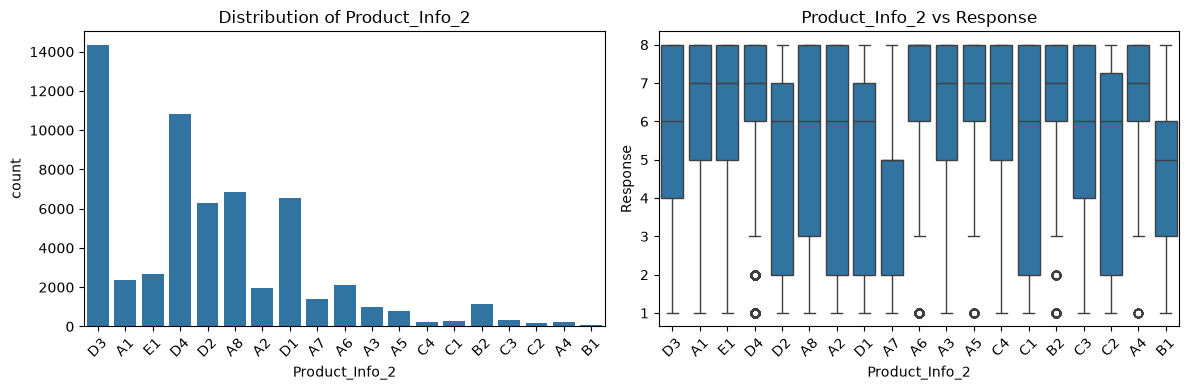

{'Shape': (59381,), 'Number of null': np.int64(0), 'Unique value': 19}

In [51]:
summary_col(df,"Product_Info_2")

The column Product_Info_3 is at index 2
Data type: int64
count    59381.000000
mean        24.415655
std          5.072885
min          1.000000
25%         26.000000
50%         26.000000
75%         26.000000
max         38.000000
Name: Product_Info_3, dtype: float64
Type: Numerical
Missing: 0
Unique: 34
Product_Info_3 is NOT normally distributed
Shapiro p-value: 0.00000
---------------------------
Spearman correlation: -0.078


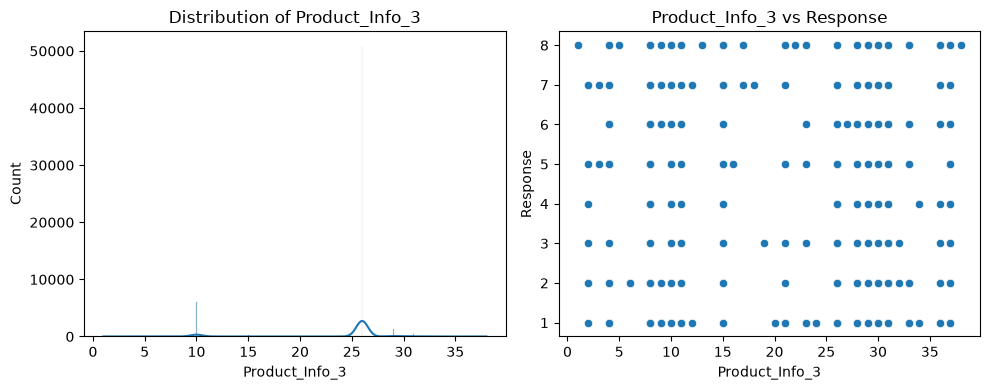

{'Shape': (59381,),
 'Number of null': np.int64(0),
 'Unique value': 34,
 'Correlation': np.float64(-0.0783860077309606)}

In [47]:
summary_col(df,"Product_Info_3")

The column Product_Info_4 is at index 3
Data type: float64
Type: Numerical
Missing: 0
Unique: 1491
Product_Info_4 is NOT normally distributed
Shapiro p-value: 0.00000
---------------------------
Spearman correlation: 0.249


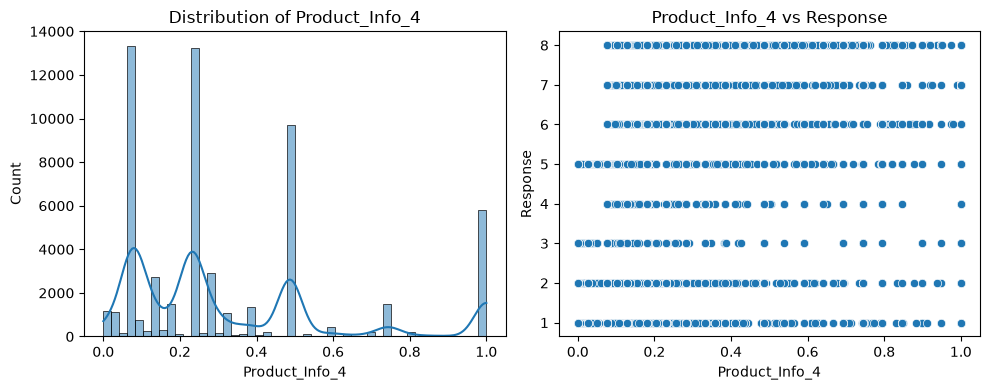

{'Shape': (59381,),
 'Number of null': np.int64(0),
 'Unique value': 1491,
 'Correlation': np.float64(0.24916712906890506)}

In [45]:
summary_col(df,"Product_Info_4")

In [52]:
df_1 = df.copy()

In [54]:
df_1.describe(include="all")

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
count,59381.000000,59381,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,...,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000
unique,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,D3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,14321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.026355,NaN,24.415655,0.328952,2.006955,2.673599,1.043583,0.405567,0.707283,0.292587,...,0.056954,0.010054,0.045536,0.010710,0.007528,0.013691,0.008488,0.019905,0.054496,5.636837
std,0.160191,NaN,5.072885,0.282562,0.083107,0.739103,0.291949,0.197190,0.074239,0.089037,...,0.231757,0.099764,0.208479,0.102937,0.086436,0.116207,0.091737,0.139676,0.226995,2.456833
min,1.000000,NaN,1.000000,0.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,NaN,26.000000,0.076923,2.000000,3.000000,1.000000,0.238806,0.654545,0.225941,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,1.000000,NaN,26.000000,0.230769,2.000000,3.000000,1.000000,0.402985,0.709091,0.288703,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,1.000000,NaN,26.000000,0.487179,2.000000,3.000000,1.000000,0.567164,0.763636,0.345188,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000


In [65]:
duplicate = df_1[df_1.duplicated()]
duplicate

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
17040,1,D3,26,1.000000,2,3,1,0.567164,0.781818,0.424686,...,0,0,0,0,0,0,0,0,0,5
18002,1,D3,26,1.000000,2,3,1,0.194030,0.781818,0.288703,...,0,0,0,0,0,0,0,0,0,8
20858,1,D2,10,0.282051,2,3,1,0.507463,0.745455,0.341004,...,0,0,0,0,0,0,0,0,0,1
21651,1,D1,26,0.230769,2,3,1,0.283582,0.800000,0.299163,...,0,0,0,0,0,0,0,0,0,4
21764,2,D2,26,0.230769,2,1,1,0.507463,0.763636,0.288703,...,0,0,0,0,0,0,0,0,0,8
26143,1,A8,26,0.230769,2,3,1,0.731343,0.672727,0.217573,...,0,0,0,0,0,0,0,0,0,8
28786,1,D3,26,0.589744,2,1,1,0.567164,0.745455,0.257322,...,0,0,0,1,0,0,0,0,0,8
31228,1,D1,26,1.000000,2,3,1,0.477612,0.727273,0.466527,...,0,0,0,0,0,0,0,0,0,5
31530,1,B2,26,0.102564,2,3,1,0.328358,0.727273,0.278243,...,0,0,0,0,0,0,0,0,0,8
33493,1,D3,26,0.230769,2,3,1,0.313433,0.854545,0.309623,...,0,0,0,0,0,0,0,0,0,8


In [66]:
print(df_1["Response"].value_counts(dropna=False))

Response
8    19489
6    11233
7     8027
2     6552
1     6207
5     5432
4     1428
3     1013
Name: count, dtype: int64


In [67]:
print(
    df_1["Response"]
    .value_counts(normalize=True, dropna=False) * 100
)

Response
8    32.820262
6    18.916825
7    13.517792
2    11.033832
1    10.452838
5     9.147707
4     2.404810
3     1.705933
Name: proportion, dtype: float64


In [68]:
print(df_1.dtypes.value_counts())

int64      108
float64     18
str          1
Name: count, dtype: int64


In [69]:
numeric_cols = df_1.select_dtypes(include="number").columns
categorical_cols = df_1.select_dtypes(exclude="number").columns

print("Numerical:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numerical: 126
Categorical: 1


In [70]:
missing = df_1.isna().sum().sort_values(ascending=False)

print(missing.head(20))

Medical_History_10     58824
Medical_History_32     58274
Medical_History_24     55580
Medical_History_15     44596
Family_Hist_5          41811
Family_Hist_3          34241
Family_Hist_2          28656
Insurance_History_5    25396
Family_Hist_4          19184
Employment_Info_6      10854
Medical_History_1       8889
Employment_Info_4       6779
Employment_Info_1         19
Product_Info_4             0
Product_Info_5             0
Employment_Info_3          0
Employment_Info_2          0
InsuredInfo_1              0
Employment_Info_5          0
InsuredInfo_3              0
dtype: int64


In [71]:
missing_percent = (
    df_1.isna().mean() * 100
).sort_values(ascending=False)

print(missing_percent.head(20))

Medical_History_10     99.061990
Medical_History_32     98.135767
Medical_History_24     93.598963
Medical_History_15     75.101463
Family_Hist_5          70.411411
Family_Hist_3          57.663226
Family_Hist_2          48.257860
Insurance_History_5    42.767889
Family_Hist_4          32.306630
Employment_Info_6      18.278574
Medical_History_1      14.969435
Employment_Info_4      11.416110
Employment_Info_1       0.031997
Product_Info_4          0.000000
Product_Info_5          0.000000
Employment_Info_3       0.000000
Employment_Info_2       0.000000
InsuredInfo_1           0.000000
Employment_Info_5       0.000000
InsuredInfo_3           0.000000
dtype: float64


In [72]:
constant_cols = [
    col for col in df_1.columns
    if df_1[col].nunique(dropna=False) <= 1
]

print(constant_cols)

[]


In [ ]:
for col in df_1.columns:
    unique_ratio = df_1[col].nunique() / len(df_1)

    if unique_ratio > 0.95:
        print(col, unique_ratio)
        

In [74]:
for col in categorical_cols:
    print("\n", col)
    print(df_1[col].value_counts().head(10))


 Product_Info_2
Product_Info_2
D3    14321
D4    10812
A8     6835
D1     6554
D2     6286
E1     2647
A1     2363
A6     2098
A2     1974
A7     1383
Name: count, dtype: int64


In [76]:
df_1["Ins_Age"].describe()

count    59381.000000
mean         0.405567
std          0.197190
min          0.000000
25%          0.238806
50%          0.402985
75%          0.567164
max          1.000000
Name: Ins_Age, dtype: float64